**Zaimplementuj algorytm optymalizacji roju cząstek (PSO).**


Zastosuj zwiększanie parametrów odpowiadających za ufność wiedzy cząstki po pewnym czasie działania algorytmu. Przy pomocy algorytmu optymalizacji rojem cząstek, naucz system ANFIS. Celem optymalizacji jest zminimalizowanie błędu osiąganego przez ANFIS (o wartościach parametrów reprezentowanych przez cząstkę) na zbiorze danych. Przetestuj działanie algorytmu PSO w zależności od zadanych parametrów. 

**Importy**

In [1]:
# -*- coding: utf-8 -*-
import numpy as np
from scipy.optimize import minimize, basinhopping
from scipy.stats import variation
import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from itertools import permutations, combinations
import time
from sklearn.model_selection import train_test_split
from helps_and_enhancers import calculate_combinations, my_reshape
from operators import productN
from types import SimpleNamespace
from params import FuzzyInputVariable_3Trapezoids, FuzzyInputVariable_2Trapezoids, FuzzyInputVariable_List_Trapezoids
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from goal_function_object import *
import pandas as pd
import random
from collections import defaultdict, Counter
import matplotlib.pyplot as plt


**kod pso**

In [2]:
def objective_function(pos):
    x, y = pos
    term1 = (1.5 - x - x * y) ** 2
    term2 = (2.25 - x + x * y ** 2) ** 2
    term3 = (2.625 - x + x * y ** 3) ** 2
    return term1 + term2 + term3


def initialize_particles(num_particles, bounds):
    bounds_min, bounds_max = bounds
    dim = len(bounds_min)
    positions = np.random.uniform(bounds_min, bounds_max, (num_particles, dim))
    velocities = np.random.uniform(-1, 1, (num_particles, dim))
    return positions, velocities


def update_velocity(velocity, position, pbest, gbest, w, c1, c2):
    r1 = np.random.rand(*position.shape)
    r2 = np.random.rand(*position.shape)
    cognitive = c1 * r1 * (pbest - position)
    social = c2 * r2 * (gbest - position)
    return w * velocity + cognitive + social


def update_position(position, velocity, bounds):
    bounds_min, bounds_max = bounds
    new_position = position + velocity
    return np.clip(new_position, bounds_min, bounds_max)


def update_pbest(positions, pbest_positions, pbest_scores, objective_func):
    for i in range(len(positions)):
        score = objective_func(positions[i])
        if score < pbest_scores[i]:
            pbest_positions[i] = positions[i].copy()
            pbest_scores[i] = score
    return pbest_positions, pbest_scores


def get_global_best(pbest_positions, pbest_scores):
    best_idx = np.argmin(pbest_scores)
    return pbest_positions[best_idx].copy(), pbest_scores[best_idx]


def pso(objective_func, num_particles=30, max_iter=100, w=0.5, c1=2.0, c2=2.0, bounds=None):
    positions, velocities = initialize_particles(num_particles, bounds)
    pbest_positions = np.copy(positions)
    pbest_scores = np.array([objective_func(pos) for pos in positions])
    gbest_position, gbest_score = get_global_best(pbest_positions, pbest_scores)

    convergence = []

    for iteration in range(max_iter):
        progress = iteration / max_iter
        c1_current = 2.0 - progress * 0.5 
        c2_current = 0.5 + progress * 1.5
        w_current = 0.9 - progress * 0.5 
        # c1_current = c1 * (1 + 0.5 * iteration / max_iter)
        # c2_current = c2 * (1 + 0.5 * iteration / max_iter)
        # w_current = w * (1 - iteration / max_iter)
        
        velocities = update_velocity(velocities, positions, pbest_positions, gbest_position, 
                                    w_current, c1_current, c2_current)
        positions = update_position(positions, velocities, bounds)
        pbest_positions, pbest_scores = update_pbest(positions, pbest_positions, pbest_scores, objective_func)
        gbest_position, gbest_score = get_global_best(pbest_positions, pbest_scores)
        convergence.append(gbest_score)

    return gbest_position, gbest_score, convergence


def pso_training(objective_func, x0, minimizer_kwargs=None, niter=100, niter_success=50, num_particles=150, w=0.9, c1=2.5, c2=0.3):
    bounds = minimizer_kwargs.get("bounds", None)
    args = minimizer_kwargs.get("args", ())
    
    if not isinstance(args, tuple):
        args = (args,)
        
    bounds_min = np.array([b[0] for b in bounds])
    bounds_max = np.array([b[1] for b in bounds])
    bounds_tuple = (bounds_min, bounds_max)
    
    def objective_wrapper(pos):
        return objective_func(pos, *args)
    
    gbest_position, gbest_score, convergence_history = pso(
        objective_wrapper,
        num_particles=num_particles,
        max_iter=niter,
        w=w,
        c1=c1,
        c2=c2,
        bounds=bounds_tuple
    )
        
    result = SimpleNamespace(
        x=gbest_position,
        fun=gbest_score,
        nfev=len(convergence_history) * num_particles,
        nit=len(convergence_history),
        convergence=convergence_history
    )
        
    return result

**Kod Anfis**

In [3]:
class ANFISPso:
    
    def __init__(self, inputs, training_data: np.ndarray, expected_labels: np.ndarray, operator_function=productN, operator_init_value=0.5):
        self.input_list = inputs
        self.input_number = len(inputs)
        self.training_data = training_data
        self.expected_labels = expected_labels
        
        self.premises = []
        for i in range(self.input_number):
            self.premises.append(self.input_list[i].get())

        self.nodes_number = np.prod([inp.n_functions for inp in self.input_list])
        
        self.operator_function=operator_function
        
        #self.tsk = np.ones((self.nodes_number ,self.input_number+1))
        self.tsk = np.random.random((self.nodes_number ,self.input_number+1))
        
        self.op  = [operator_init_value]*self.nodes_number

        self.calculate_aids()

    #Wyswietlanie funkcji przynależnosci
    def show_inputs(self):
        plt.figure()
        for i in range(self.input_number):
            plt.subplot(self.input_number, 1, i+1)
            self.input_list[i].show()
            plt.legend()
        plt.show()

    def set_premises_parameters(self, fv):
        fv = np.array(fv).reshape(np.shape(self.premises))
        self.premises=fv
        for i in range(self.input_number):
            self.input_list[i].set(*fv[i])
             
    def calculate_aids(self):
        self.premises_combinations = np.array(calculate_combinations(self))[:,::-1]

    def output_to_labels(self, y_pred):
        rounded = np.round(y_pred.flatten()).astype(int)
        r_shape = np.shape(rounded)
        return np.max((np.min((rounded , np.ones(r_shape)),axis=0), np.zeros(r_shape)),axis=0)#clamp 0-1       
               
    def anfis_estimate_labels(self, fv, op, tsk) -> np.ndarray:

        data = self.training_data

        self.set_premises_parameters(fv)
        tsk=np.reshape(tsk,np.shape(self.tsk))
        memberships = [self.input_list[x].fuzzify(data[x]) for x in range(self.input_number)]
        
        #Wnioskowanie
        arguments = []
        for premises in self.premises_combinations:
            item = []
            for i in range(len(premises)):
                item.append(np.array(memberships[i])[:,premises[i]])
            arguments.append(   item  )

        arguments = np.transpose(arguments, (1,2,0))
        
        R=self.operator_function(arguments, op)
        
        #Normalizacja normalizacja poziomów aktywacji reguł
        Rsum = np.sum(R, axis=1, keepdims=True)

        Rnorm = R / Rsum
        Rnorm[(Rsum==0).flatten(),:] = 0
        # wylicz wartoci przesłanek dla każdej próbki
        
        dataXYZ1 = np.vstack((self.training_data,np.ones(len(self.training_data[0])))).T
        Q = np.dot(dataXYZ1, tsk.T) 
        
        # wyznacz wyniki wnioskowania dla każdej próbki
        result = (Q * Rnorm).sum(axis=1, keepdims=True)
    
        return result.T    
        
    def show_results(self, color=None):
        
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        
        if color is None:
            color = [[1,0,0] if cc else [0,1,0] for cc in self.expected_labels]

        result = self.anfis_estimate_labels(self.premises,self.op,self.tsk)
        
        #ax.scatter(np.array(self.training_data)[:,0], np.array(self.training_data)[:,1], result, c=rgb)
        ax.scatter(self.training_data[0], self.training_data[1], result, c=color)
        
        plt.show()
    
    def set_training_and_testing_data(self, training_data, expected_labels):
        self.training_data = training_data
        self.expected_labels = expected_labels
        
    def train(self, global_optimization: bool, learn_premises: bool, learn_operators: bool, learn_consequents: bool, n_iter=100, bounds_premises=None):
        
        x1 = [ item for sublist in self.premises for item in sublist ]
        x1 = np.array(x1).flatten()
        x2 = self.op
        x3 = self.tsk.flatten()
          
        if bounds_premises is None:
            bfv = [(0,4)]*len(x1)
        else:
            bfv = bounds_premises
        bop  = [(0.0,2.0)]*len(x2)
        btsk = [(0,2)]*len(x3)
        
        niter_success=100
            
        if learn_premises and learn_operators and learn_consequents:
            x0 = np.hstack((x1,x2,x3))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)+len(x2)
            
            bounds = bfv + bop + btsk

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self)}
                res = pso_training(goal_premises_operators_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises_operators_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:self.end_x1].reshape(np.shape(self.premises)))
            self.op=res.x[self.end_x1:self.end_x2]
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))
            
        elif learn_premises and learn_operators:
            x0 = np.hstack((x1,x2))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)+len(x2)
            
            bounds = bfv + bop

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = pso_training(goal_premises_operators, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises_operators, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:self.end_x1].reshape(np.shape(self.premises)))
            self.op=res.x[self.end_x1:self.end_x2]

        elif learn_premises and learn_consequents:
            x0 = np.hstack((x1,x3))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)
            
            bounds = bfv + btsk

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self)}
                res = pso_training(goal_premises_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter)#, niter_success=niter_success)
            else:
                res = minimize(goal_premises_consequents, x0, method='SLSQP', bounds=bounds, args=self, tol=1e-6)

            self.set_premises_parameters(res.x[:self.end_x1]) ##zmiana funkcji
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))

        elif learn_operators and learn_consequents:
            print("4")
            x0 = np.hstack((x2,x3))
            self.end_x1 = 0
            self.end_x2 = len(x2)
            
            bounds = bop + btsk

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = pso_training(goal_operators_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_operators_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.op=res.x[self.end_x1:self.end_x2]
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))
        
        elif learn_premises:
            x0 = x1
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)
            
            bounds = bfv

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = pso_training(goal_premises, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:].reshape(np.shape(self.premises)))

        elif learn_operators:
            x0 = x2
            self.end_x1 = 0
            self.end_x2 = len(x2)
            
            bounds = bop

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = pso_training(goal_operators, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_operators, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.op=res.x[:]
            
        elif learn_consequents:
            x0 = x3
            self.end_x1 = 0
            self.end_x2 = 0
            
            bounds = btsk

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self), "tol":1e-03}
                res = pso_training(goal_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.tsk=res.x[:].reshape(np.shape(self.tsk))
            
        else:
            print("Error")
            assert(0)
            
        print("Optymalizacja zakończona!")
        print("z blędem:  ", res.fun)
        print("Liczba ew: ", res.nfev)
        print("Liczba it: ", res.nit)


**Sprawdzenie** 

Tabliczka: 2x2


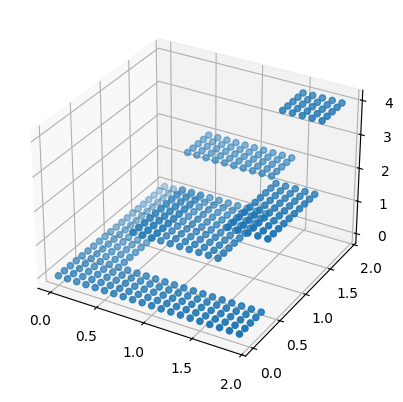

C:\Users\Filip\AppData\Local\Temp\ipykernel_17068\3860796310.py:70: RuntimeWarning: invalid value encountered in divide
  Rnorm = R / Rsum


Optymalizacja zakończona!
z blędem:   25.11073242457693
Liczba ew:  1200000
Liczba it:  8000


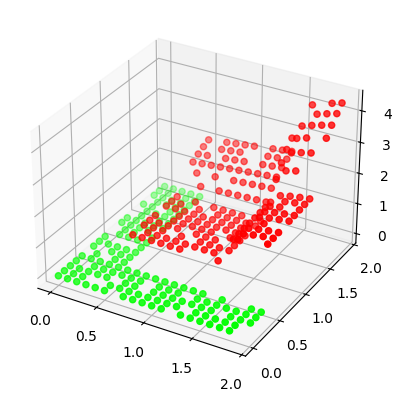

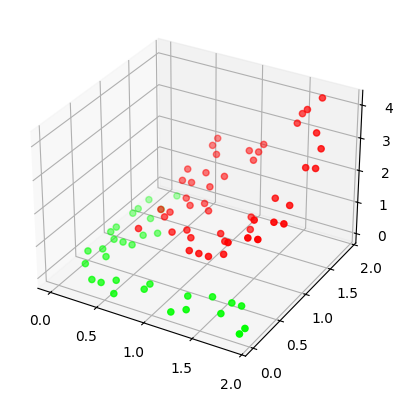

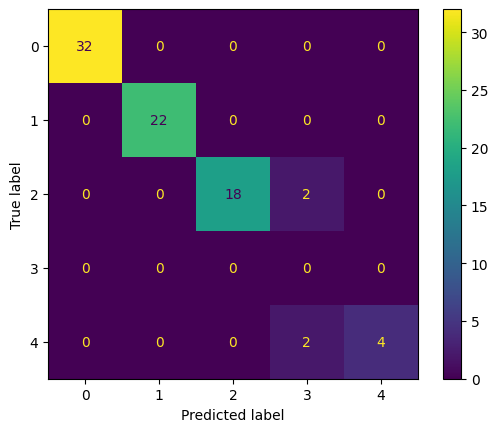

Tabliczka: 3x3


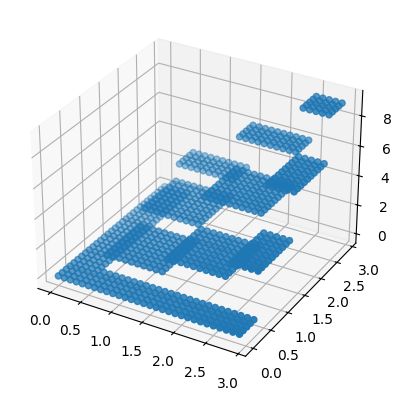

C:\Users\Filip\AppData\Local\Temp\ipykernel_17068\3860796310.py:70: RuntimeWarning: invalid value encountered in divide
  Rnorm = R / Rsum


Optymalizacja zakończona!
z blędem:   185.38369159977907
Liczba ew:  2700000
Liczba it:  18000


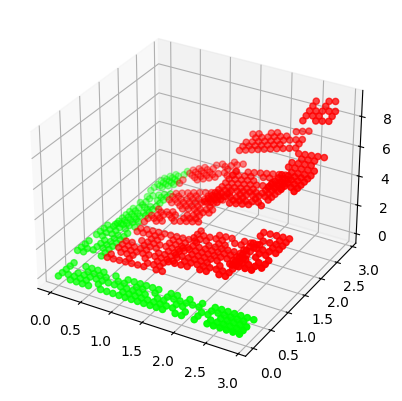

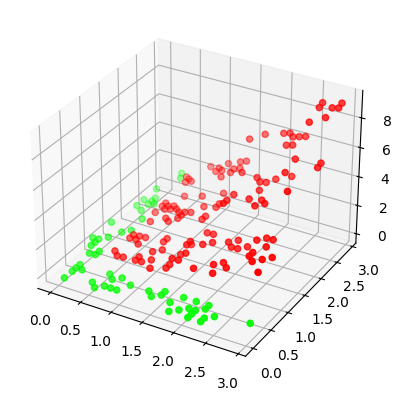

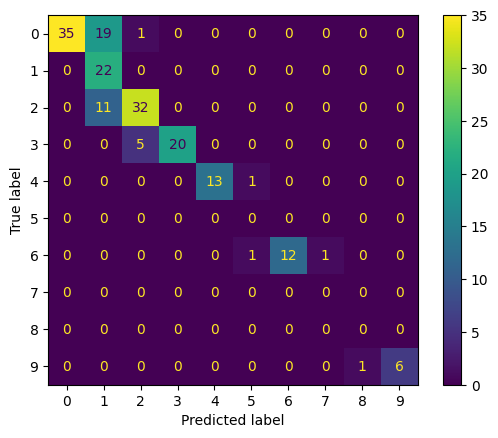

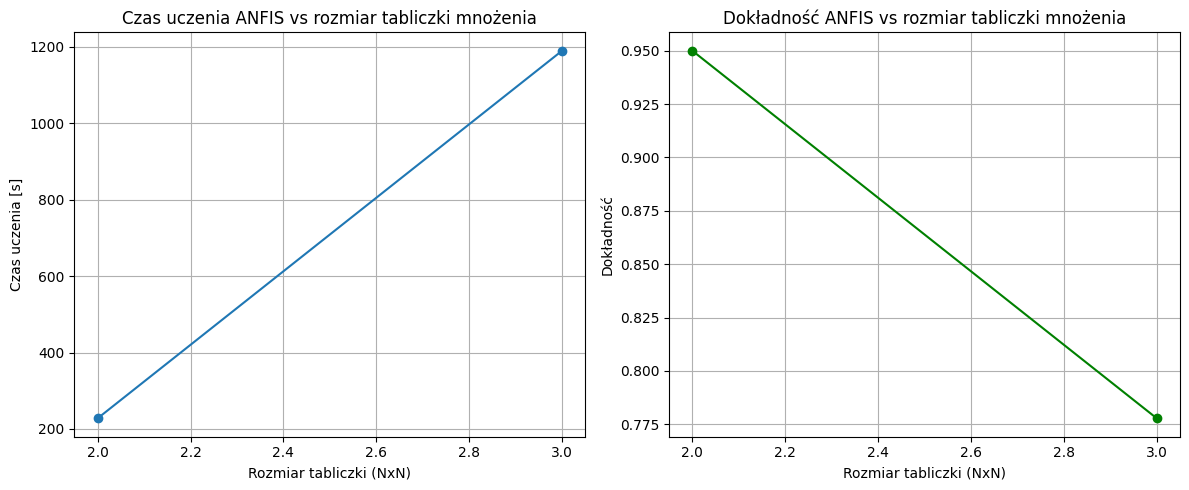

In [4]:
from sklearn.metrics import accuracy_score

sizes = [2, 3]
times = []
accuracies = []

mf1 = [
        [-0.25, 0.125, 0.125, 0.25], 
        [0.25, 0.125, 0.1, 0.1], 
        [0.5, 0.25, 0.1, 0.1], 
        [0.75, 0.25, 0.125, 1.25],
        [1.25, 0.75, -0.25, 1.25],
         [1.5, 0.4, 0.2, 0.5]
    ]
    
labels = ["L","H", "M", "S", "XL", "XS"]

def custom_round(val):
    return int(val + 0.5)

for size in sizes:
    print(f"Tabliczka: {size}x{size}")

    x = np.arange(0, size, 0.1)
    x,y = np.meshgrid(x, x)

    dataX = x.flatten()
    dataY = y.flatten()
    dataXY = np.column_stack((dataX,dataY))   

    data_labels = [custom_round(a) * custom_round(b) for a, b in dataXY]

    # for x in range(len(dataXY)):
    #     print(x, dataXY[x], data_labels[x])

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(dataX, dataY, data_labels)
    plt.show()

    # varX = FuzzyInputVariable_2Trapezoids(0.5, 0.5, "XAxis", ["L","H"]) 
    # varY = FuzzyInputVariable_2Trapezoids(0.5, 0.5, "YAxis", ["L","H"])

    varX = FuzzyInputVariable_List_Trapezoids(mf1[:size+1], "XAxis", labels[:size+1])
    varY = FuzzyInputVariable_List_Trapezoids(mf1[:size+1], "YAxis", labels[:size+1])

    X_train, X_test, y_train, y_test = train_test_split(dataXY, data_labels, test_size=0.2, random_state=25)

    fis = ANFISPso([varX, varY], X_train.T, y_train)

    start = time.time()
    fis.train(True, True, False, True, n_iter=2000*size*size)
    end = time.time()
    times.append(end-start)
    fis.training_data = X_train.T
    fis.expected_labels = y_train
    fis.show_results()

    fis.training_data = X_test.T
    fis.expected_labels = y_test
    fis.show_results()

    y_pred = fis.anfis_estimate_labels(fis.premises,fis.op,fis.tsk)
    y_pred = list(map(round,y_pred.flatten()))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.show()

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(sizes, times, marker='o')
axs[0].set_xlabel('Rozmiar tabliczki (NxN)')
axs[0].set_ylabel('Czas uczenia [s]')
axs[0].set_title('Czas uczenia ANFIS vs rozmiar tabliczki mnożenia')
axs[0].grid(True)

axs[1].plot(sizes, accuracies, marker='o', color='green')
axs[1].set_xlabel('Rozmiar tabliczki (NxN)')
axs[1].set_ylabel('Dokładność')
axs[1].set_title('Dokładność ANFIS vs rozmiar tabliczki mnożenia')
axs[1].grid(True)

plt.tight_layout()
plt.show()
